# Cloud statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import requests
from datetime import datetime
from astropy.time import Time
from astropy.coordinates import get_sun

In [2]:
clouds = pd.read_hdf('clouds_ctio_blanco.h5').set_index(['date', 'quarter'])

In [3]:
clouds.head()

sday  eday  month  year  clouds source
date       quarter                                        
1975-01-01 1           1     2      1  1975       0   ctio
           2           1     2      1  1975       0   ctio
           3           1     2      1  1975       0   ctio
           4           1     2      1  1975       0   ctio
1975-01-02 1           2     3      1  1975       0   ctio

In [4]:
# Initial draft of code generated by claude 4.5 sonnet, then heavily human modified

def download_ersst_data(start_date='1975-01-01', cache_dir='./ersst_cache', verbose=False):
    """
    Download ERSST v6 data and cache it locally.
    
    Parameters:
    -----------
    start_date : str
        Start date in 'YYYY-MM-DD' format
    cache_dir : str
        Directory to store cached NetCDF files
        
    Returns:
    --------
    xarray.Dataset
        Combined dataset with all monthly data
    """
    cache_path = Path(cache_dir)
    cache_path.mkdir(exist_ok=True)
    
    # ERSST v6 data is stored in monthly NetCDF files
    base_url = "https://www.ncei.noaa.gov/data/sea-surface-temperature-extended-reconstructed/v6/access/"
    
    # Parse start date
    start = pd.to_datetime(start_date)
    
    # Get current date
    current = datetime.now()
    
    # Generate list of year-month combinations
    date_range = pd.date_range(start=start, end=current, freq='MS')
    
    datasets = []
    
    for date in date_range:
        # Format: ersst.v6.YYYYMM.nc
        year_month = date.strftime('%Y%m')
        filename = f"ersst.v6.{year_month}.nc"
        local_file = cache_path / filename
        
        # Check if file exists in cache
        if not local_file.exists():
            print(f"Downloading {filename}...")
            url = base_url + filename
            try:
                response = requests.get(url, timeout=60)
                response.raise_for_status()
                
                with open(local_file, 'wb') as f:
                    f.write(response.content)
                print(f"Downloaded {filename}")
            except requests.exceptions.RequestException as e:
                print(f"Warning: Could not download {filename}: {e}")
                # If we can't download recent months, they may not be available yet
                if date.year == current.year and date.month >= current.month - 2:
                    print(f"  (This is expected for very recent months)")
                continue
        else:
            if verbose:
                print(f"Using cached {filename}")
        
        # Load the NetCDF file
        try:
            ds = xr.open_dataset(local_file)
            datasets.append(ds)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            continue
    
    # Combine all datasets
    if datasets:
        combined_ds = xr.concat(datasets, dim='time')
        return combined_ds
    else:
        raise ValueError("No data could be loaded")

def extract_region34_temperatures(dataset):
    """
    Extract mean temperatures for the Niño 3.4 region.
    
    Niño 3.4 region: 5°N-5°S, 120°W-170°W
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        ERSST dataset
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with 'date' and 'temperature' columns
    """
    # Define region 3.4 (used for El Nino) boundaries
    lat_min, lat_max = -5, 5
    lon_min, lon_max = 190, 240  # Convert from 120°W-170°W to 0-360° convention
    
    # Select the region
    # ERSST uses longitude in 0-360 format
    region34 = dataset.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )
    
    # Extract SST variable (usually named 'sst')
    sst = region34['sst']
    
    # Calculate spatial mean over region 3.4
    # Weight by cosine of latitude for proper area averaging
    weights = np.cos(np.deg2rad(sst.lat))
    sst_weighted = sst.weighted(weights)
    region34_mean = sst_weighted.mean(dim=['lat', 'lon'])
    
    # Convert to pandas DataFrame
    df = region34_mean.to_dataframe(name='temperature').reset_index()
    
    # Keep only time and temperature columns
    df = df[['time', 'temperature']].rename(columns={'time': 'date'})
    
    # Sort by date
    df = df.sort_values('date').reset_index(drop=True)
    
    return df


ersst_data = download_ersst_data(start_date='1975-01-01', cache_dir='./ersst_cache')
    
# Extract and save ersst data in the Niño 3.4 region
ersst34 = extract_region34_temperatures(ersst_data)

# Save
ersst34.to_hdf('ersst_temperatures.h5', key='region34')

  (This is expected for very recent months)


In [5]:
ersst34.head()

,date,temperature
0,1975-01-15,26.050095
1,1975-02-15,26.115588
2,1975-03-15,26.286232
3,1975-04-15,26.926890
4,1975-05-15,26.903447


In [6]:
clouds['solar_longitude'] = get_sun(Time(clouds.index.get_level_values('date'))).geocentrictrueecliptic.lon.deg
clouds['season_number'] = (((clouds['solar_longitude'] - 270) % 360) // 90).astype(int)
season_names = {
    0: 'summer',
    1: 'fall',
    2: 'winter',
    3: 'spring'
}
clouds['season'] = pd.Categorical(clouds['season_number'].map(season_names), categories=[season_names[s] for s in np.arange(4)], ordered=True)
clouds.head()

sday  eday  month  year  clouds source  solar_longitude  \
date       quarter                                                            
1975-01-01 1           1     2      1  1975       0   ctio       280.275221   
           2           1     2      1  1975       0   ctio       280.275221   
           3           1     2      1  1975       0   ctio       280.275221   
           4           1     2      1  1975       0   ctio       280.275221   
1975-01-02 1           2     3      1  1975       0   ctio       281.294124   

                    season_number  season  
date       quarter                         
1975-01-01 1                    0  summer  
           2                    0  summer  
           3                    0  summer  
           4                    0  summer  
1975-01-02 1                    0  summer

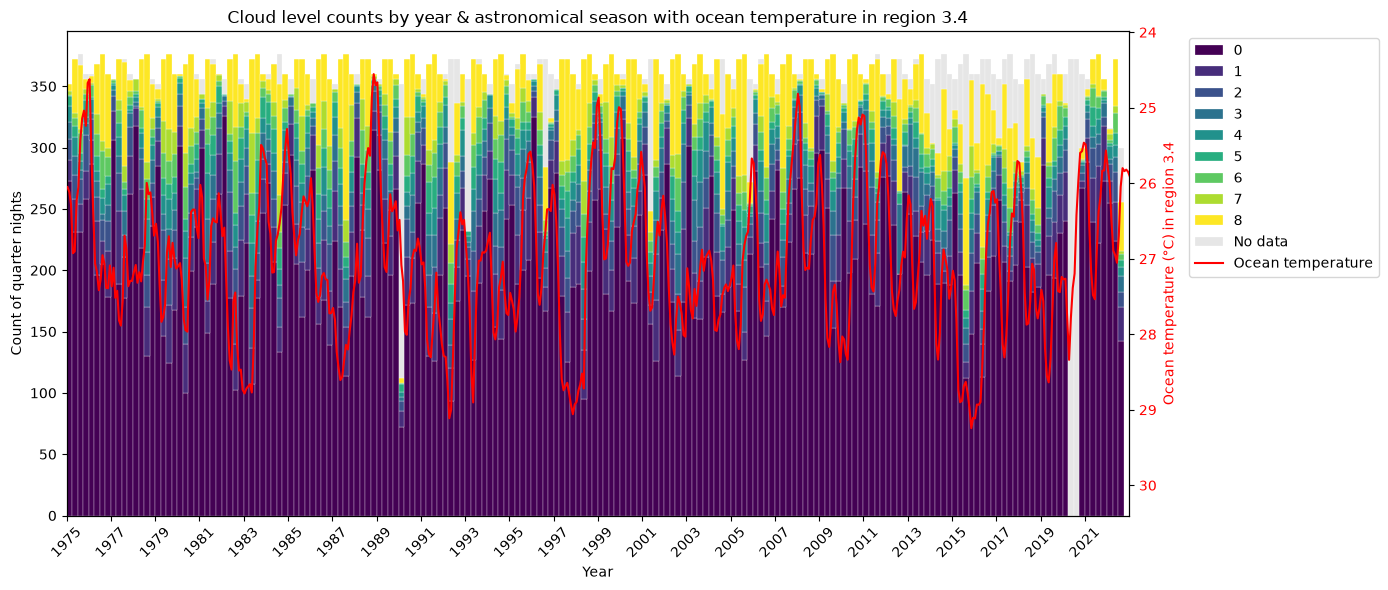

In [7]:
# Initial draft of code generated by kimi-k2.7-code, then heavily human modified

x = clouds.year + clouds.season_number.to_numpy()/4 + 0.125

x_by_level = [
    x[clouds['clouds'] == level].values
    for level in range(10)
]

min_year = int(clouds.year.min())
max_year = int(clouds.year.max())
bins = np.arange(min_year, max_year + 1.001, 0.25)

colors = [plt.cm.viridis(level / 8) for level in range(9)] + ['0.9']
labels = [str(level) for level in range(9)] + ['No data']

fig, ax = plt.subplots(figsize=(14, 6))
hist_counts, hist_edges, hist_patches = ax.hist(
    x_by_level,
    bins=bins,
    stacked=True,
    color=colors,
    label=labels,
    edgecolor='white',
    linewidth=0.2
)
ax.set_xlabel('Year')
ax.set_ylabel('Count of quarter nights')
ax.set_title('Cloud level counts by year & astronomical season with ocean temperature in region 3.4')

tick_step = 2
ax.set_xticks(np.arange(min_year, max_year + 1, tick_step))
ax.tick_params(axis='x', rotation=45)

# Region 3.4 temperature on the right y-axis
temp_color = 'red'
ax_temp = ax.twinx()
nino_dates = pd.to_datetime(ersst34['date'])
nino_years = nino_dates.dt.year + (nino_dates.dt.dayofyear - 1) / 365.25
line_temp = ax_temp.plot(
    nino_years,
    ersst34['temperature'],
    color=temp_color,
    linewidth=1.5,
    label='Niño 3.4',
    zorder=3
)
ax_temp.set_ylabel('Ocean temperature (°C) in region 3.4', color=temp_color)
ax_temp.tick_params(axis='y', labelcolor=temp_color)

# Invert the temperature axis so hotter is at the bottom
ax_temp.invert_yaxis()

# Scale the temperature limits to make it easy to compare with
# numbers of clear (cloud=0) quarters
clear_stats = pd.Series(hist_counts[0]).describe()
clear_iqr = float(clear_stats['75%'] - clear_stats['25%'])
clear_median = float(clear_stats['50%'])
temp_stats = ersst34.temperature.describe()
temp_iqr = float(temp_stats['75%'] - temp_stats['25%'])
temp_median = float(temp_stats['50%'])
cloud_ylim = ax.get_ylim()
cloud_yheight = cloud_ylim[1]-cloud_ylim[0]
temp_yheight = cloud_yheight * temp_iqr / clear_iqr
median_frac_from_bottom = (clear_median - cloud_ylim[0])/cloud_yheight
max_temp_lim = temp_median + temp_yheight * median_frac_from_bottom
min_temp_lim = max_temp_lim - temp_yheight
ax_temp.set_ylim(max_temp_lim, min_temp_lim)

# Combined legend
handles, labels = ax.get_legend_handles_labels()
handles.append(line_temp[0])
labels.append('Ocean temperature')
ax.legend(
    handles,
    labels,
    title=None,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
ax.set_xlim(bins.min(), bins.max())

plt.tight_layout()
plt.show()

In [8]:
ax.figure.savefig('clouds_temps_by_season.png')

In [9]:
# Add ocean temperature to cloud data

clouds = clouds.reset_index().set_index(['year', 'month'])
ersst34['year'] = ersst34['date'].dt.year
ersst34['month'] = ersst34['date'].dt.month
ersst34 = ersst34.set_index(['year', 'month'])
clouds['region34_temperature'] = ersst34['temperature']
clouds = clouds.reset_index().set_index(['date', 'quarter'])
clouds


year  month  sday  eday  clouds  source  solar_longitude  \
date       quarter                                                             
1975-01-01 1        1975      1     1     2       0    ctio       280.275221   
           2        1975      1     1     2       0    ctio       280.275221   
           3        1975      1     1     2       0    ctio       280.275221   
           4        1975      1     1     2       0    ctio       280.275221   
1975-01-02 1        1975      1     2     3       0    ctio       281.294124   
...                  ...    ...   ...   ...     ...     ...              ...   
2022-09-03 4        2022      9     3     4       0  blanco       160.178339   
2022-09-04 1        2022      9     4     5       0  blanco       161.146788   
           2        2022      9     4     5       0  blanco       161.146788   
           3        2022      9     4     5       0  blanco       161.146788   
           4        2022      9     4     5       0  blanco       161.146788   

                    season_number  season  region34_temperature  
date       quarter                                               
1975-01-01 1                    0  summer             26.050095  
           2                    0  summer             26.050095  
           3                    0  summer             26.050095  
           4                    0  summer             26.050095  
1975-01-02 1                    0  summer             26.050095  
...                           ...     ...                   ...  
2022-09-03 4                    2  winter             25.800176  
2022-09-04 1                    2  winter             25.800176  
           2                    2  winter             25.800176  
           3                    2  winter             25.800176  
           4                    2  winter             25.800176  

[69652 rows x 10 columns]

In [10]:
clear_limit = 3
clouds['clear'] = clouds.clouds <= clear_limit
clouds_by_season = clouds.groupby(['season', 'year']).agg({'clear': 'mean', 'region34_temperature': 'mean'})
clouds_by_season


clear  region34_temperature
season year                                
summer 1975  0.911932             25.983686
       1976  0.911111             25.623885
       1977  0.974719             27.313656
       1978  0.946629             27.124465
       1979  0.923295             26.856197
...               ...                   ...
spring 2017  0.730337             26.111963
       2018  0.611111             27.657945
       2019  0.811111             27.336612
       2020  0.794444             25.591731
       2021  0.943820             25.797444

[191 rows x 2 columns]

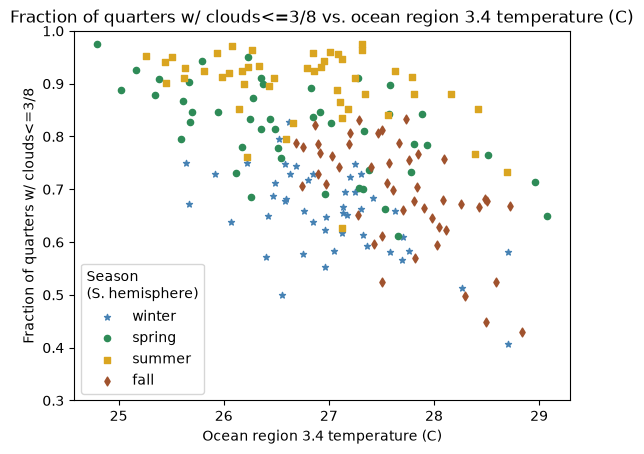

In [11]:
ax = None
season_color = {
    'winter': 'steelblue',
    'spring': 'seagreen',
    'summer': 'goldenrod',
    'fall': 'sienna'
}
season_marker = {
    'winter': '*',
    'spring': 'o',
    'summer': 's',
    'fall': 'd'
}
for season in ['winter', 'spring', 'summer', 'fall']:
    ax = clouds_by_season.loc[season, :].plot.scatter('region34_temperature', 'clear', color=season_color[season], marker=season_marker[season], label=season, ax=ax)

ax.set_ylim(0.3, 1.0)
ax.set_title(f'Fraction of quarters w/ clouds<={clear_limit}/8 vs. ocean region 3.4 temperature (C)')
ax.set_ylabel(f'Fraction of quarters w/ clouds<={clear_limit}/8')
ax.set_xlabel('Ocean region 3.4 temperature (C)')
ax.legend(loc='lower left', title="Season\n(S. hemisphere)")

In [12]:
# ax.figure.savefig('clear_vs_temps.png')